# Milestone 1: Import Dataset, Initialize Repository
Liam — CSC 475, Music Maven (Group 4)



This notebook handles dataset loading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

## Configuration
Set `M4A_ROOT` local path

In [2]:
M4A_ROOT = "/Users/liamleibel/Music4All"

# Acoustic features
MIR_FEATURES = ["tempo", "energy", "valence", "danceability", "key", "mode"]

# Extra metadata referenced w/ features
META_COLS = ["song_id", "artist_id", "artist_name", "album", "year", "genres", "tags"]

## Dataset Loading

Music4All stores per-song data across several CSV files. The expected layout is:
```
Music4All/
    id_information.csv   — song_id, artist_id, artist_name, album, year
    id_mir.csv           — song_id, tempo, energy, valence, danceability, key, mode
    id_genres.csv        — song_id, genres (comma-separated)
    id_tags.csv          — song_id, tags  (comma-separated)
```
All four are joined on `song_id`. Adjust column names inside `load_m4a()` to match your local copy if they differ.

In [3]:
def load_m4a(root):

    paths = {
        "info":     os.path.join(root, "id_information.csv"),
        "metadata": os.path.join(root, "id_metadata.csv"),
        "genres":   os.path.join(root, "id_genres.csv"),
        "tags":     os.path.join(root, "id_tags.csv"),
    }
    for p in paths.values():
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing: {p}")

    info     = pd.read_csv(paths["info"],     sep="\t")
    metadata = pd.read_csv(paths["metadata"], sep="\t")
    genres   = pd.read_csv(paths["genres"],   sep="\t")
    tags     = pd.read_csv(paths["tags"],     sep="\t")

    songs = (
        info
        .merge(metadata, on="id", how="left")
        .merge(genres,   on="id", how="left")
        .merge(tags,     on="id", how="left")
    )

    songs = songs.rename(columns={
        "id":      "song_id",
        "artist":  "artist_name",
        "release": "year",
    })

    names = songs["artist_name"].str.strip()
    uniq  = {n: f"A{i+1:05d}" for i, n in enumerate(sorted(names.unique()))}
    songs["artist_id"] = names.map(uniq)

    songs = songs.dropna(subset=MIR_FEATURES, how="all").reset_index(drop=True)
    print(f"Loaded Music4All data: {len(songs):,} songs")
    return songs

In [4]:
songs = load_m4a(M4A_ROOT)

print(f"Songs: {len(songs):,}")
print(f"Unique artists: {songs['artist_id'].nunique()}")
print(f"Columns: {list(songs.columns)}\n")
songs.head()

Loaded Music4All data: 109,269 songs
Songs: 109,269
Unique artists: 16269
Columns: ['song_id', 'artist_name', 'song', 'album_name', 'spotify_id', 'popularity', 'year', 'danceability', 'energy', 'key', 'mode', 'valence', 'tempo', 'duration_ms', 'genres', 'tags', 'artist_id']



,song_id,artist_name,song,album_name,spotify_id,popularity,year,danceability,energy,key,mode,valence,tempo,duration_ms,genres,tags,artist_id
0,0009fFIM1eYThaPg,Cheryl,Rain on Me,3 Words,3eObKIfHKJ1nAPh0wTxFCc,12.0,2009,0.635,0.746,6.0,1.0,0.548,110.973,229947,pop,"pop,british,female vocalists,dance,cheryl cole",A02644
1,0010xmHR6UICBOYT,Oddisee,After Thoughts,The Beauty in All,27szvF97Tu95GxN98N52fy,46.0,2013,0.591,0.513,7.0,0.0,0.263,172.208,325096,underground hip hop,"instrumental hip-hop,underground hip hop,instr...",A10353
2,002Jyd0vN4HyCpqL,Blue Öyster Cult,ME 262,Secret Treaties,273lBFpxUCwisTpdnF9cVb,31.0,1974,0.319,0.925,2.0,1.0,0.658,157.630,285693,"hard rock,rock,classic rock","hard rock,rock,classic rock,american artist",A01850
3,006TYKNjNxWjfKjy,Rhapsody,Flames of Revenge,Legendary Years (Re-Recorded),1qZgergQ41vaD4zBf3AKXR,33.0,2017,0.432,0.979,7.0,1.0,0.162,90.008,332867,"symphonic metal,power metal,symphonic power metal","symphonic metal,power metal,symphonic power metal",A11568
4,007LIJOPQ4Sb98qV,The Chameleons,Nostalgia,What Does Anything Mean? Basically (2009 Remas...,6rVxJ3sN3Cz40MSLavbG1K,19.0,2009,0.357,0.708,9.0,1.0,0.470,123.904,326067,"post-punk,new wave","post-punk,new wave,1985",A13725


## Schema Exploration


In [5]:
# check MIR feature coverage and basic statistics
print("=== MIR Feature Summary ===")
display(songs[MIR_FEATURES].describe().round(3))

print("\n=== Missing Values ===")
missing = songs[MIR_FEATURES].isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values in MIR features.")

=== MIR Feature Summary ===


,tempo,energy,valence,danceability,key,mode
count,109269.000,109269.000,109269.000,109269.000,109269.000,109269.000
mean,122.753,0.667,0.446,0.520,5.284,0.625
std,28.998,0.241,0.252,0.173,3.561,0.484
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,100.194,0.502,0.236,0.403,2.000,0.000
50%,121.079,0.712,0.424,0.528,5.000,1.000
75%,140.047,0.872,0.639,0.645,9.000,1.000
max,242.903,1.000,0.998,0.988,11.000,1.000



=== Missing Values ===
No missing values in MIR features.


In [6]:
# songs-per-artist distribution
songs_per_artist = songs.groupby("artist_id").size()
print("Songs per artist:")
print(songs_per_artist.describe().round(1))
single_song = (songs_per_artist == 1).sum()
total_artists = len(songs_per_artist)
print(f"\nArtists with only 1 song: {single_song} ({single_song/total_artists*100:.0f}% of all artists)")
print("These are dropped by the min_songs=2 filter in Milestone 2.")
print("~42% of artists — a known characteristic of the dataset.")

Songs per artist:
count    16269.0
mean         6.7
std         13.8
min          1.0
25%          1.0
50%          2.0
75%          6.0
max        264.0
dtype: float64

Artists with only 1 song: 6887 (42% of all artists)
These are dropped by the min_songs=2 filter in Milestone 2.
~42% of artists — a known characteristic of the dataset.


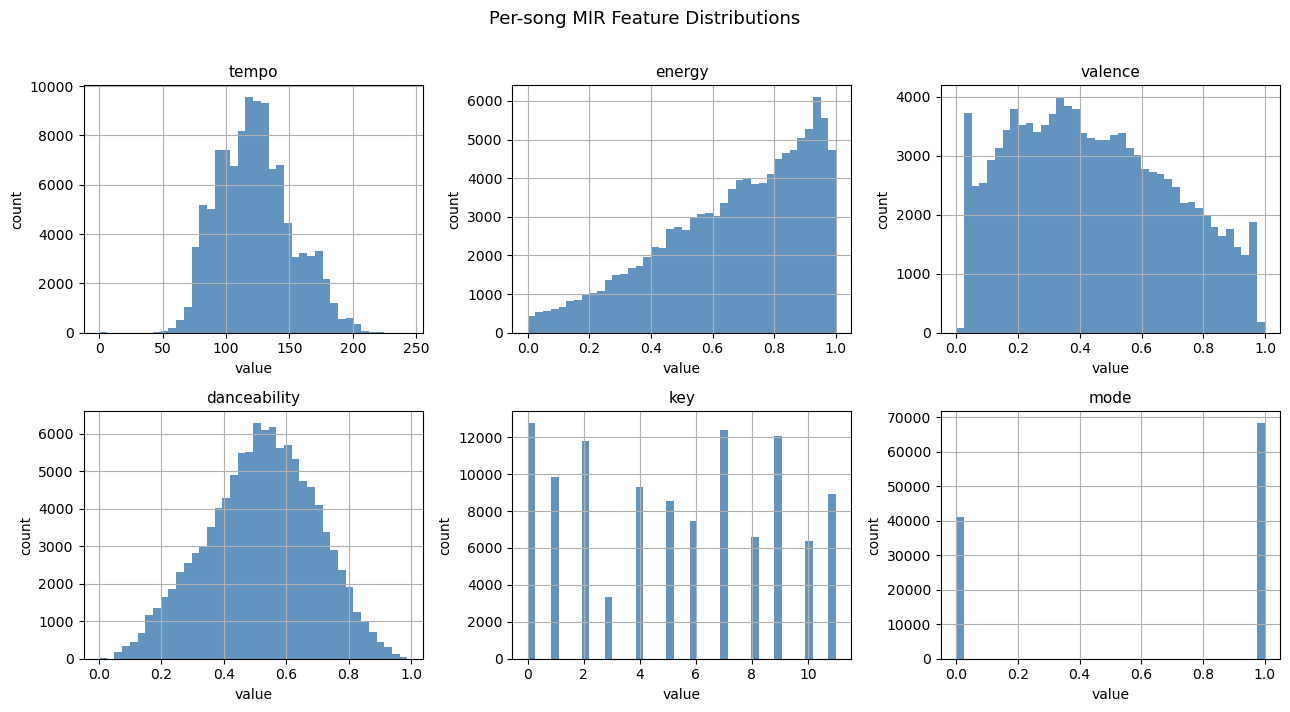

Note: tempo (~60–200) is on a very different scale to energy/valence/danceability (0–1).
Normalization in Milestone 2 handles this.

Note: 18 songs have tempo=0 - likely Spotify API errors.
These are filtered out before saving (see next cell).


In [7]:
# feature distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

axes = axes.flatten()

for ax, feat in zip(axes, MIR_FEATURES):
    songs[feat].dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

fig.suptitle("Per-song MIR Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Note: tempo (~60–200) is on a very different scale to energy/valence/danceability (0–1).")
print("Normalization in Milestone 2 handles this.")

print(f"\nNote: {(songs['tempo'] == 0).sum()} songs have tempo=0 - likely Spotify API errors.")
print("These are filtered out before saving (see next cell).")

## Save Output for Milestone 2
Write the cleaned per-song DataFrame to a CSV so Milestone 2 can load it directly.

In [8]:
# drop songs with any missing MIR feature value before handing off
songs_clean = songs.dropna(subset=MIR_FEATURES).reset_index(drop=True)
print(f"Songs after dropping incomplete MIR rows: {len(songs_clean):,} "
      f"(dropped {len(songs) - len(songs_clean)})")

# filter tempo=0 — these are Spotify API errors (no song has 0 BPM)
before = len(songs_clean)
songs_clean = songs_clean[songs_clean["tempo"] > 0].reset_index(drop=True)
print(f"Songs after removing tempo=0 anomalies: {len(songs_clean):,} "
      f"(dropped {before - len(songs_clean)})")

songs_clean.to_csv("songs.csv", index=False)
print("Saved: songs.csv")

Songs after dropping incomplete MIR rows: 109,269 (dropped 0)
Songs after removing tempo=0 anomalies: 109,251 (dropped 18)
Saved: songs.csv


In [9]:
from pathlib import Path

path = Path.home() / "Music4All"
print(path.resolve())

/Users/liamleibel/Music4All
